MAX Momentum Strategy Backtest
==============================

Implements the MAX(N) metric: ranks assets by the average of their N highest
daily returns over a lookback window, then goes long the top decile and short
the bottom decile.

Based on: "MAX Momentum in the Cryptocurrency Market".

In [28]:
n_max = "1"          # N in MAX(N): average of top-N daily returns
lookback_days = "30" # Lookback window for metric calculation
holding_days = "7"   # Rebalance / holding period in days
universe_top_n = "300" # Universe size: top N coins by dollar volume
n_deciles = "5"     # Number of decile buckets for cross-sectional ranking
start_date = "2023-01-01"

In [29]:
import polars as pl
import numpy as np
import datetime as dt
import scrapbook as sb
import backtest as bt

n_max_P = int(n_max)
lookback_P = int(lookback_days)
holding_P = int(holding_days)
universe_P = int(universe_top_n)
n_deciles_P = int(n_deciles)
start_date_P = dt.datetime.strptime(start_date, "%Y-%m-%d").replace(
    tzinfo=dt.timezone.utc
)

assert n_max_P > 0, "N must be a positive integer"
assert lookback_P >= n_max_P, "Lookback window must be at least as large as N"
assert holding_P > 0, "Holding period must be positive"
assert universe_P > 0, "Universe size must be positive"
assert n_deciles_P >= 2, "Need at least 2 decile buckets"

print(
    f"""
Running MAX({n_max_P}) Momentum backtest
Lookback: {lookback_P}d  |  Rebalance: {holding_P}d  |  Universe: top {universe_P} by volume
Deciles: {n_deciles_P}  |  Long top, Short bottom
"""
)


Running MAX(1) Momentum backtest
Lookback: 30d  |  Rebalance: 7d  |  Universe: top 300 by volume
Deciles: 5  |  Long top, Short bottom



In [30]:
# Load data and compute features BEFORE start_date filter to allow warm-up
df = (
    pl.read_parquet("stables-1d.parquet")
    .with_columns(pl.col("ts").dt.cast_time_unit("us"))
    .sort(["symbol", "ts"])
    .with_columns(
        ret=pl.col("close").pct_change().over("symbol"),
    )
    .with_columns(
        max_metric=pl.col("ret").rolling_max(lookback_P).over("symbol"),
        volume_rank=pl.col("quote_volume").rank(descending=True).over("ts"),
    )
    .filter(pl.col("ts") >= start_date_P)
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1202/1202 [00:10<00:00, 110.71it/s]


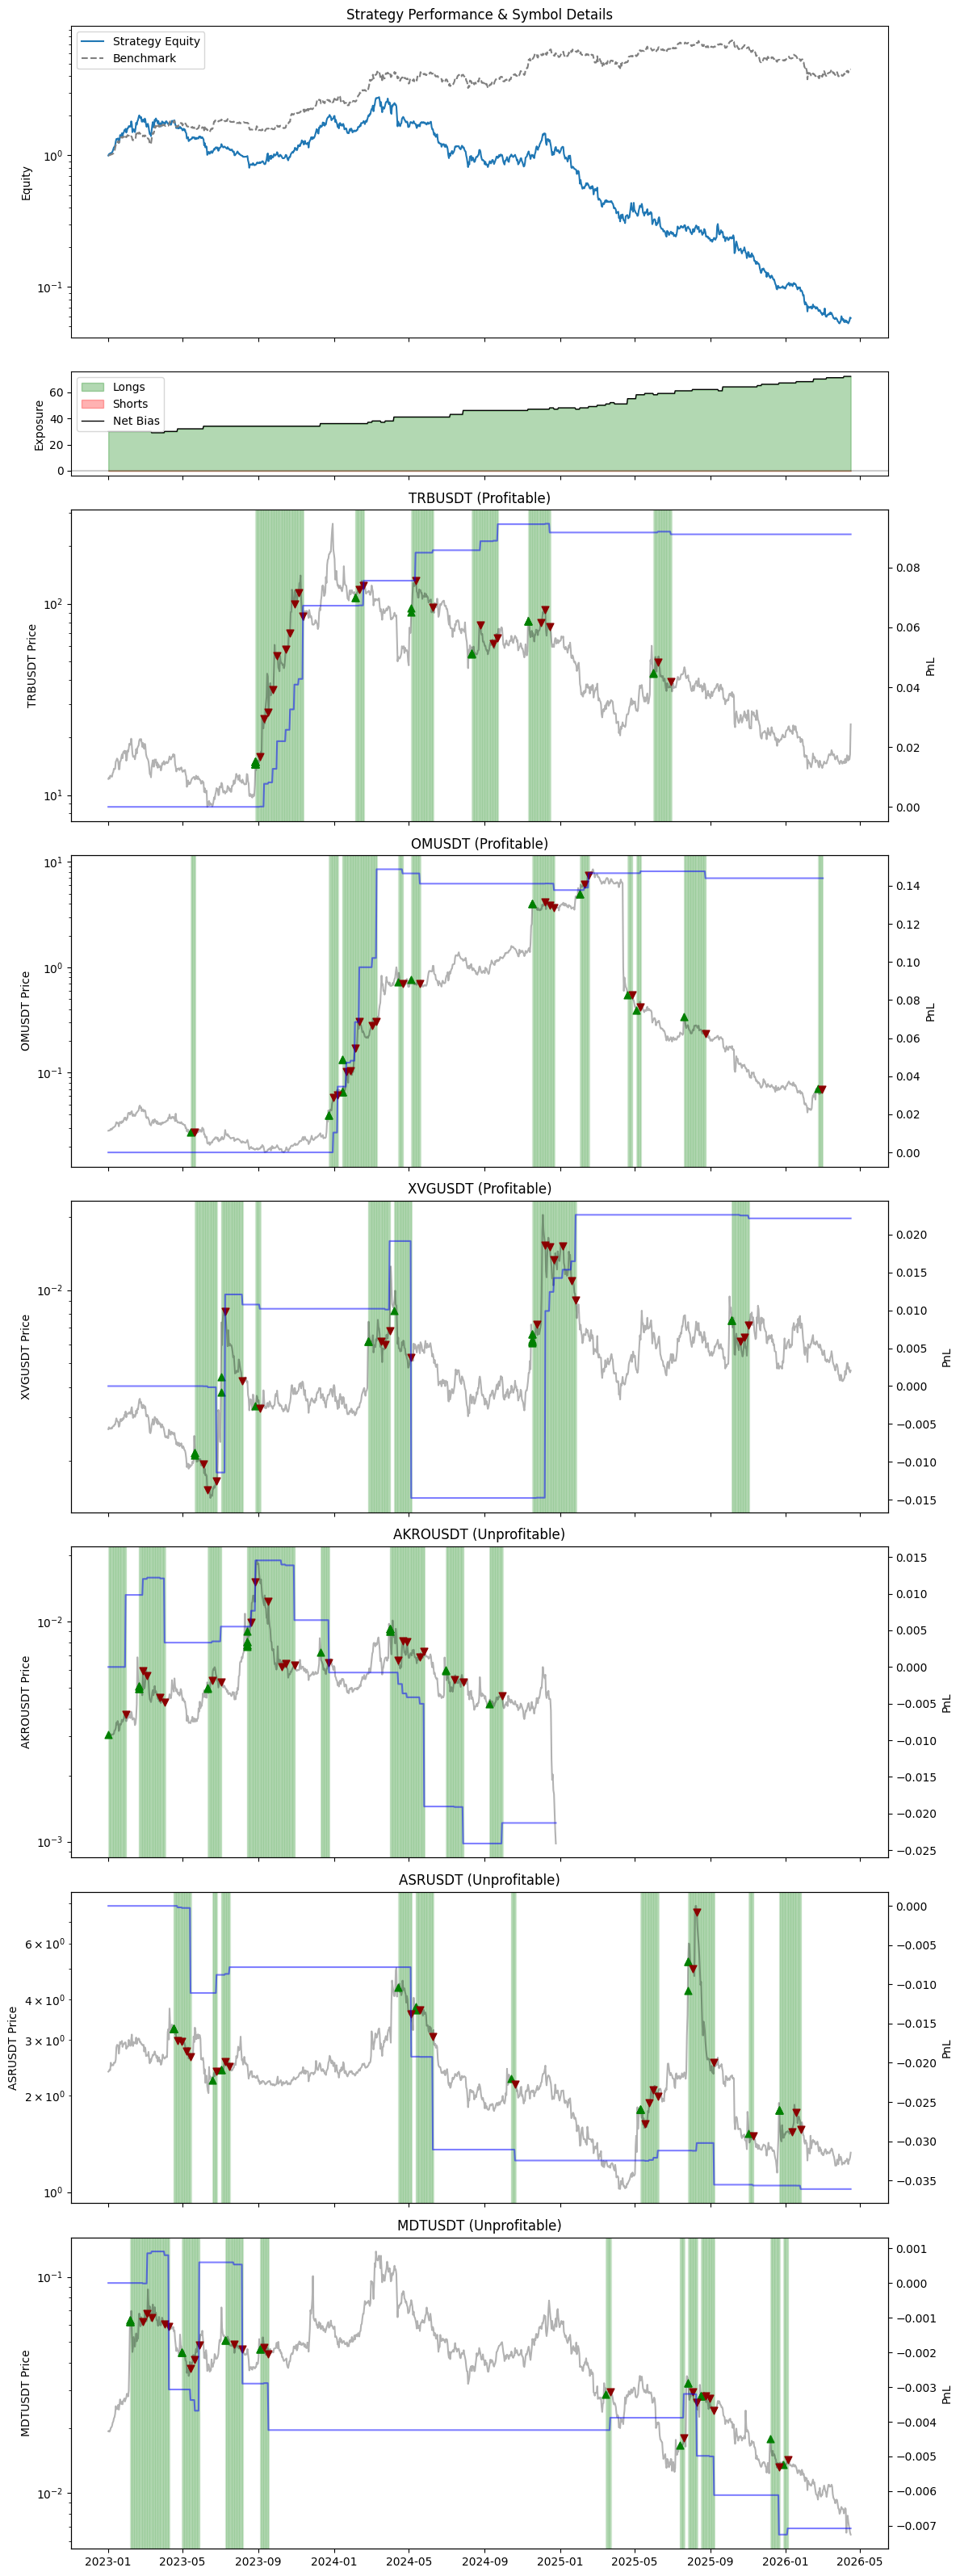

In [31]:
class MaxMomentumAlpha(bt.AlphaModel):
    """
    Cross-sectional alpha based on the MAX(N) metric.

    Emits bullish signals for the top decile and bearish signals for the
    bottom decile within the liquid universe.
    """

    def __init__(self, universe_top_n: int, n_deciles: int = 10):
        self.universe_top_n = universe_top_n
        self.n_deciles = n_deciles

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)

        if dfnow.is_empty():
            return []

        labels = [str(i) for i in range(self.n_deciles)]
        ranked = (
            dfnow.filter(
                (pl.col("volume_rank") <= self.universe_top_n)
                    & pl.col("max_metric").is_not_null()
                    & pl.col("max_metric").is_finite()
                    )
                .with_columns(
                    decile=pl.col("max_metric")
                    .qcut(10, labels=[str(i) for i in range(10)]) # Decile sorting [2]
                    .over("ts")
                    )
                .select(["ts", "symbol", "decile"])
                )

        top = str(self.n_deciles - 1)
        bottom = "0"

        signals: list[bt.Signal] = []
        for row in ranked.filter(pl.col("decile") == "9").iter_rows(named=True):
            signals.append(bt.Signal(row["symbol"], bullish=True, confidence=1.0))
        #for row in ranked.filter(pl.col("decile") == "0").iter_rows(named=True):
        #    signals.append(bt.Signal(row["symbol"], bullish=False, confidence=1.0))

        return signals


# Use 2x leverage so the long and short legs each get 100% of equity,
# matching the original's arithmetic: strategy_ret = mean(top_decile) − mean(bottom_decile).
# EqualWeight alone would only give 50% gross on each leg (equity split across all signals).
test = bt.Backtest(
    df,
    alpha=MaxMomentumAlpha(universe_P, n_deciles_P),
    portfolio=bt.EqualWeight(),
    risk=bt.NoRisk(),
    period=holding_P,
    benchmark="BTCUSDT",
)

test.run()
res = test.report(plot=True)

In [32]:
for col in set(res.columns) - {"year", "src"}:
    s = res.filter(pl.col("src") == "Strategy")
    b = res.filter(pl.col("src") == "Benchmark")

    val = s[col].mean() if not s.is_empty() else None
    bench_val = b[col].mean() if not b.is_empty() else None

    if val is not None and (np.isnan(val) or np.isinf(val)):
        val = None

    print(f"{col}: {val} ({bench_val})")
    sb.glue(col, float(val) if val is not None else None)

cagr: -0.32794277414614953 (0.5392919824305933)


sharpe: -0.7296193854370745 (0.7260092599090153)


ann_std: 0.6436802410544205 (0.4060924061755335)


maxdd: -0.6835445798199739 (-0.2832221370182145)


win_rate: 0.4368808991543412 (None)


...

sortino: -1.1181133409083426 (1.456598453091342)


fees: 0.055604975009848005 (None)


ann_return: -0.4935008717813683 (0.27878014408699253)


mae_std: 0.14199063237417756 (None)


mfe_std: 6.725910461468703 (None)
